# 01 — MVP H2/H3 · Huginn latent trajectories (Kaggle)

**Перед запуском в Kaggle:** справа Settings → Accelerator = **GPU P100**, Internet = **On**
(без интернета не скачается ни модель, ни датасет). Аккаунт должен быть верифицирован по телефону.

После установки в следующей ячейке сделай **Run → Restart & clear cell outputs**, затем прогоняй сверху вниз.

Inference-only: извлекаем траекторию скрытого состояния Huginn, меряем форму (settle/loop/drift),
winding и steps-to-settle против глубины рассуждения (PARARULE) и длины счёта (синтетика, H3).

In [5]:
!pip install -q "transformers==4.53.3" datasets accelerate
# После установки: Run -> Restart kernel, затем продолжай со следующей ячейки.

In [6]:
import os, random
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from sklearn.decomposition import PCA
from scipy.stats import spearmanr, rankdata
from tqdm import tqdm

MODEL_ID = "tomg-group-umd/huginn-0125"
MODEL_REVISION = "bb6621b65e90b6a4b9b29ef88dc83866d450470c"   # заморозка remote-кода

In [7]:
CACHE = "/kaggle/working"        # на Kaggle сохраняется как output ноутбука
os.makedirs(CACHE, exist_ok=True)

def cached(name, compute_fn):
    path = os.path.join(CACHE, name)
    if os.path.exists(path):
        print("loaded", path); return pd.read_csv(path)
    df = compute_fn(); df.to_csv(path, index=False); print("computed+saved", path)
    return df

In [8]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION, torch_dtype=torch.bfloat16, trust_remote_code=True
).to("cuda").eval()
tok = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
print("loaded")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

loaded


In [9]:
def get_trajectory(prompt, num_steps=64, seed=0, token_index=-1):
    mod = model.transformer.core_block[-1]; mod._forward_hooks.clear()
    lat = []
    h = mod.register_forward_hook(lambda m, i, o: lat.append(o.detach().float().cpu()))
    try:
        torch.manual_seed(seed)
        ids = tok(prompt, return_tensors="pt").input_ids.to("cuda")
        with torch.no_grad():
            model(input_ids=ids, num_steps=num_steps)     # int, не tensor!
    finally:
        h.remove()
    return torch.stack([l[0, token_index, :] for l in lat]).numpy()

def winding_number(pts, center=None):
    c = pts.mean(0) if center is None else center
    v = pts - c
    ang = np.arctan2(v[:, 1], v[:, 0])
    d = np.diff(ang); d = (d + np.pi) % (2*np.pi) - np.pi
    return float(d.sum() / (2*np.pi))

def winding_of(traj, burn=4):
    return winding_number(PCA(2).fit_transform(traj[burn:]))   # burn-in: отбрасываем начальную дугу

def step_norms(traj):
    return np.linalg.norm(np.diff(traj, axis=0), axis=1)

def steps_to_settle(traj, frac=0.1):
    s = step_norms(traj); below = np.where(s < frac*s.max())[0]
    return int(below[0]) if len(below) else len(s)

def classify_shape(traj, settle_frac=0.1, return_frac=0.25):
    from scipy.spatial.distance import pdist, squareform
    s = step_norms(traj)
    if s[-1] < settle_frac*s.max(): return "settle"
    D = squareform(pdist(traj)); n = len(traj)
    mask = np.abs(np.subtract.outer(range(n), range(n))) > 3
    return "loop" if D[mask].min()/(D.max()+1e-9) < return_frac else "drift"

def partial_spearman(x, y, z):
    xr, yr, zr = rankdata(x), rankdata(y), rankdata(z)
    rx = xr - np.polyval(np.polyfit(zr, xr, 1), zr)
    ry = yr - np.polyval(np.polyfit(zr, yr, 1), zr)
    return spearmanr(rx, ry)

## A. Санити: детектор settle работает?
На «2+3» ждём settle и затухающую норму шага.

shape (64, 5280) | class: settle | steps_to_settle: 12 | winding: -0.616


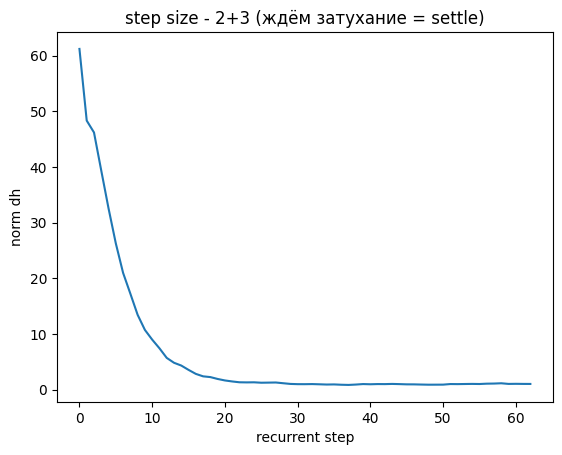

In [10]:
t = get_trajectory("Q: 2+3=? A:", num_steps=64)
print("shape", t.shape, "| class:", classify_shape(t),
      "| steps_to_settle:", steps_to_settle(t), "| winding:", round(winding_of(t), 3))
plt.plot(step_norms(t)); plt.xlabel("recurrent step"); plt.ylabel("norm dh")
plt.title("step size - 2+3 (ждём затухание = settle)"); plt.show()

## B. PARARULE-Plus: winding / steps-to-settle vs глубина рассуждения
Датасет с встроенной меткой глубины (2-5). Сначала смотрим поля, потом грузим.

In [11]:
ds0 = load_dataset("qbao775/PARARULE-Plus-Depth-2", split="train")
print(ds0.column_names); print(ds0[0])

README.md: 0.00B [00:00, ?B/s]

Depth2/PARARULE_Plus_Depth2_shuffled_tra(…):   0%|          | 0.00/65.1M [00:00<?, ?B/s]

Depth2/PARARULE_Plus_Depth2_shuffled_dev(…):   0%|          | 0.00/11.8M [00:00<?, ?B/s]

(…)s_Depth2_shuffled_test_huggingface.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/89952 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16204 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2708 [00:00<?, ? examples/s]

['id', 'context', 'question', 'label', 'meta']
{'id': 'NegationRule-Animal-D2-3081', 'context': 'The bald eagle is sleepy. The bald eagle is rough. The leopard is heavy. The leopard is fierce. The bald eagle visits the rabbit. The leopard sees the dog. The rabbit is nice. The dog is nice. The dog is furry. The dog is lovely. If something is not nice then it needs the rabbit. If something needs the rabbit then it is slow. If something is not round then it is heavy. If something is not strong then it is cute. If something is furry then it is lovely. If something is lovely and not big then it is small. If something is heavy and not round then it is awful. If something is sleepy and rough then it is big. If something is big and not lovely then it is fierce. All cute animals are beautiful.', 'question': 'The bald eagle is awful.', 'label': 1, 'meta': {'QDep': '2', 'QCat': '0_not_notTrue'}}


In [12]:
DEPTH_REPOS = {d: f"qbao775/PARARULE-Plus-Depth-{d}" for d in (2,3,4,5)}
CTX, Q, LAB = "context", "question", "label"

def load_pararule(depth, n=15):
    ds = load_dataset(DEPTH_REPOS[depth], split="train").shuffle(seed=0).select(range(n))
    for i, ex in enumerate(ds):
        yield {"prompt": f"{ex[CTX]}\nQuestion: {ex[Q]}\nAnswer:",
               "depth": depth, "label": int(ex[LAB]), "prompt_id": f"d{depth}_{i}"}

def enrich(row):
    row["seq_len"] = int(tok(row["prompt"], return_tensors="pt").input_ids.shape[1])  # L - конфаундер
    row["answer_token_index"] = -1
    return row

print(enrich(next(load_pararule(2, n=1))))

{'prompt': 'The dinosaur is sleepy. The dinosaur is dull. The dinosaur is lazy. The dinosaur needs the squirrel. The wolf visits the rabbit. The wolf is strong. The wolf is heavy. The squirrel is nice. The squirrel is quiet. The squirrel is kind. The rabbit is lovely. The rabbit is small. The rabbit is furry. Nice animals are lovely. If something is dull then it likes the squirrel. If something likes the squirrel then it is slow. If something is sleepy and dull then it is lazy. If something is lovely and small then it is cute. If something is strong and heavy then it is awful. All lazy animals are rough. All lovely animals are small. All awful animals are fierce. All cute animals are beautiful.\nQuestion: The squirrel is not small.\nAnswer:', 'depth': 2, 'label': 0, 'prompt_id': 'd2_0', 'seq_len': 164, 'answer_token_index': -1}


In [13]:
def compute_pararule():
    rows = []
    for depth in (2,3,4,5):
        for row in tqdm(list(load_pararule(depth, n=10)), desc=f"depth {depth}"):   # n=10 для скорости
            row = enrich(row)
            tr = get_trajectory(row["prompt"], num_steps=64, seed=0)
            row["winding"], row["shape"], row["steps_settle"] = winding_of(tr,4), classify_shape(tr), steps_to_settle(tr)
            rows.append(row)
    return pd.DataFrame(rows)

df = cached("pararule.csv", compute_pararule)

depth 2: 100%|██████████| 10/10 [02:26<00:00, 14.66s/it]


README.md: 0.00B [00:00, ?B/s]

Depth3/PARARULE_Plus_Depth3_shuffled_tra(…):   0%|          | 0.00/80.7M [00:00<?, ?B/s]

Depth3/PARARULE_Plus_Depth3_shuffled_dev(…):   0%|          | 0.00/14.5M [00:00<?, ?B/s]

(…)s_Depth3_shuffled_test_huggingface.jsonl: 0.00B [00:00, ?B/s]

...

Generating train split:   0%|          | 0/90022 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16150 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2692 [00:00<?, ? examples/s]

depth 5: 100%|██████████| 10/10 [04:29<00:00, 26.97s/it]

computed+saved /kaggle/working/pararule.csv


In [14]:
print(df.groupby("depth")[["seq_len","winding","steps_settle"]].mean().round(3), "\n")
print(df.groupby("depth")["shape"].value_counts(), "\n")
rho, p = spearmanr(df["winding"], df["depth"])
print(f"Spearman winding~depth: rho={rho:.3f}, p={p:.3f}")
print("partial winding~depth | L:", [round(v,3) for v in partial_spearman(df["winding"], df["depth"], df["seq_len"])])

       seq_len  winding  steps_settle
depth                                
2        145.5    0.052          20.2
3        183.2   -0.005          20.3
4        216.3   -0.219          22.2
5        255.8    0.221          22.0 

depth  shape 
2      settle    10
3      settle    10
4      settle    10
5      settle    10
Name: count, dtype: int64 

Spearman winding~depth: rho=-0.037, p=0.822
partial winding~depth | L: [np.float64(-0.234), np.float64(0.146)]


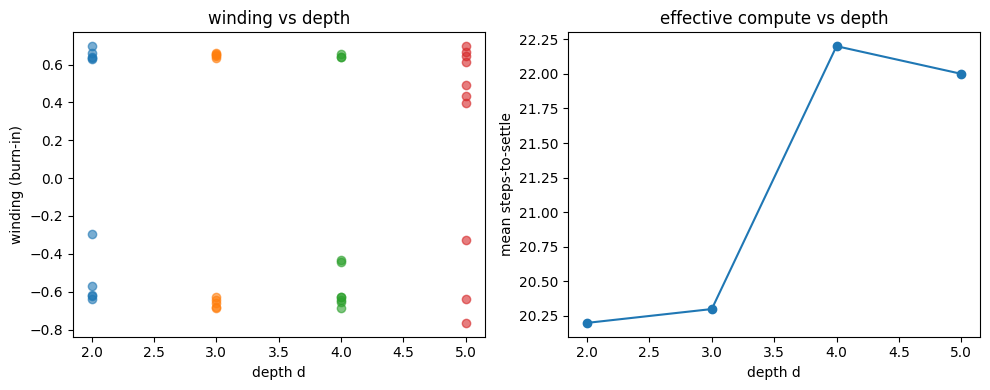

In [15]:
os.makedirs(os.path.join(CACHE, "figures"), exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(10,4))
for d in (2,3,4,5):
    sub = df[df.depth==d]; ax[0].scatter([d]*len(sub), sub["winding"], alpha=.6)
ax[0].set(xlabel="depth d", ylabel="winding (burn-in)", title="winding vs depth")
df.groupby("depth")["steps_settle"].mean().plot(marker="o", ax=ax[1])
ax[1].set(xlabel="depth d", ylabel="mean steps-to-settle", title="effective compute vs depth")
plt.tight_layout(); plt.savefig(f"{CACHE}/figures/h2_probe.png", dpi=150, bbox_inches="tight"); plt.show()

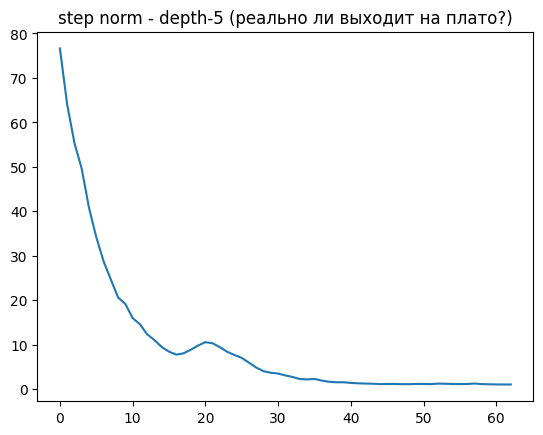

In [16]:
t5 = get_trajectory(next(load_pararule(5,1))["prompt"], num_steps=64)
plt.plot(step_norms(t5)); plt.title("step norm - depth-5 (реально ли выходит на плато?)"); plt.show()

## C. Синтетика счёта (режим H3)
Бегущая сумма +-1: чтобы ответить, модель обязана держать счётчик. Глубина = число операций n_ops.
|winding| т.к. знак PCA-проекции произволен.

In [17]:
def make_counting_task(n_ops, seed=0):
    rng = random.Random(seed)
    ops = [rng.choice([1, -1]) for _ in range(n_ops)]
    text = "Start at 0. " + " ".join("Add 1." if o > 0 else "Subtract 1." for o in ops) + " Final total? A:"
    return {"prompt": text, "n_ops": n_ops, "answer": sum(ops)}
print(make_counting_task(4, 0))

{'prompt': 'Start at 0. Subtract 1. Subtract 1. Add 1. Subtract 1. Final total? A:', 'n_ops': 4, 'answer': -2}


In [18]:
def compute_counting():
    rows = []
    for n_ops in tqdm((2, 4, 8, 16, 24, 32), desc="n_ops"):
        for s in range(5):
            task = make_counting_task(n_ops, seed=s)
            tr = get_trajectory(task["prompt"], num_steps=64, seed=0)
            rows.append({"n_ops": n_ops,
                         "seq_len": int(tok(task["prompt"], return_tensors="pt").input_ids.shape[1]),
                         "winding": abs(winding_of(tr, burn=4)),
                         "shape": classify_shape(tr),
                         "steps_settle": steps_to_settle(tr)})
    return pd.DataFrame(rows)

cdf = cached("counting.csv", compute_counting)
print(cdf.groupby("n_ops")[["seq_len","winding","steps_settle"]].mean().round(2))
print(cdf.groupby("n_ops")["shape"].value_counts())

n_ops: 100%|██████████| 6/6 [03:57<00:00, 39.58s/it]

computed+saved /kaggle/working/counting.csv
       seq_len  winding  steps_settle
n_ops                                
2         16.0     0.61          12.6
4         22.0     0.62          12.6
8         34.0     0.62          13.4
16        58.0     0.63          14.0
24        82.0     0.64          15.0
32       106.0     0.65          14.6
n_ops  shape 
2      settle    5
4      settle    5
8      settle    5
16     settle    5
24     settle    5
32     settle    5
Name: count, dtype: int64


Spearman steps_settle~n_ops: [np.float64(0.718), np.float64(0.0)]
Spearman |winding|~n_ops:    [np.float64(0.554), np.float64(0.002)]
partial |winding|~n_ops | L: [np.float64(0.042), np.float64(0.824)]


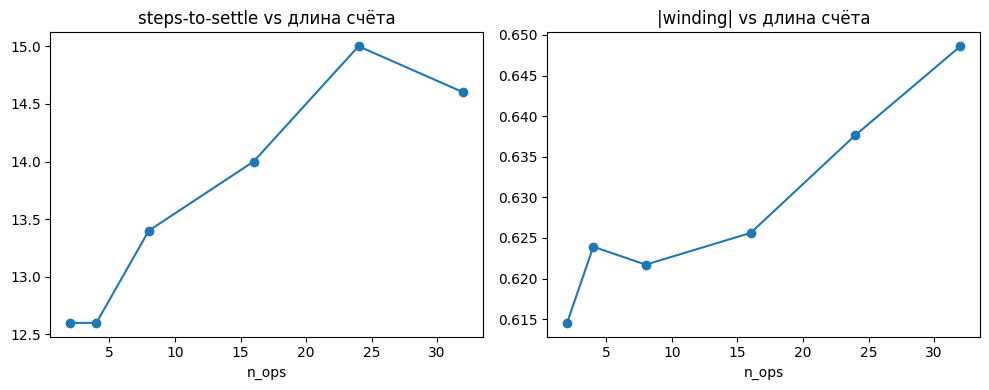

In [19]:
print("Spearman steps_settle~n_ops:", [round(v,3) for v in spearmanr(cdf.n_ops, cdf.steps_settle)])
print("Spearman |winding|~n_ops:   ", [round(v,3) for v in spearmanr(cdf.n_ops, cdf.winding)])
print("partial |winding|~n_ops | L:", [round(v,3) for v in partial_spearman(cdf.winding, cdf.n_ops, cdf.seq_len)])

fig, ax = plt.subplots(1, 2, figsize=(10,4))
cdf.groupby("n_ops")["steps_settle"].mean().plot(marker="o", ax=ax[0], title="steps-to-settle vs длина счёта"); ax[0].set_xlabel("n_ops")
cdf.groupby("n_ops")["winding"].mean().plot(marker="o", ax=ax[1], title="|winding| vs длина счёта"); ax[1].set_xlabel("n_ops")
plt.tight_layout(); plt.savefig(f"{CACHE}/figures/h3_counting.png", dpi=150, bbox_inches="tight"); plt.show()

## D. Length-matched контроль (killer-эксперимент)
`track` и `local` одной длины (тело идентично, отличается только вопрос). Если track растёт с n_ops,
а local нет -> эффект гонит удержание состояния, а не длина промпта. Это ядро результата (H3).

In [20]:
def make_variants(n_ops, seed=0):
    rng = random.Random(seed)
    ops = [rng.choice([1, -1]) for _ in range(n_ops)]
    body = "Start at 0. " + " ".join("Add 1." if o > 0 else "Subtract 1." for o in ops)
    return {"track": body + " Final total? A:",                   # нужна аккумуляция
            "local": body + " What was the last instruction? A:"}  # тот же текст, нужен только последний

def compute_ctrl():
    rows = []
    for n_ops in tqdm((4, 8, 16, 24, 32, 48), desc="n_ops"):
        for s in range(5):
            v = make_variants(n_ops, seed=s)
            for kind in ("track", "local"):
                tr = get_trajectory(v[kind], num_steps=64, seed=0)
                rows.append({"n_ops": n_ops, "kind": kind,
                             "seq_len": int(tok(v[kind], return_tensors="pt").input_ids.shape[1]),
                             "winding": abs(winding_of(tr, burn=4)),
                             "steps_settle": steps_to_settle(tr)})
    return pd.DataFrame(rows)

ctrl = cached("dissociation.csv", compute_ctrl)
print(ctrl.groupby(["kind","n_ops"])[["seq_len","winding","steps_settle"]].mean().round(2))
for kind in ("track", "local"):
    s = ctrl[ctrl.kind == kind]
    print(kind, "| winding~n_ops:", [round(v,3) for v in spearmanr(s.n_ops, s.winding)],
                "| steps~n_ops:",   [round(v,3) for v in spearmanr(s.n_ops, s.steps_settle)])

n_ops: 100%|██████████| 6/6 [10:00<00:00, 100.00s/it]

computed+saved /kaggle/working/dissociation.csv
             seq_len  winding  steps_settle
kind  n_ops                                
local 4         25.0     0.68          15.2
      8         37.0     0.66          14.6
      16        61.0     0.67          13.2
      24        85.0     0.64          13.8
      32       109.0     0.63          13.8
      48       157.0     0.62          13.0
track 4         22.0     0.62          12.6
      8         34.0     0.62          13.4
      16        58.0     0.63          14.0
      24        82.0     0.64          15.0
      32       106.0     0.65          14.6
      48       154.0     0.63          14.6
track | winding~n_ops: [np.float64(0.353), np.float64(0.056)] | steps~n_ops: [np.float64(0.612), np.float64(0.0)]
local | winding~n_ops: [np.float64(-0.348), np.float64(0.059)] | steps~n_ops: [np.float64(-0.672), np.float64(0.0)]


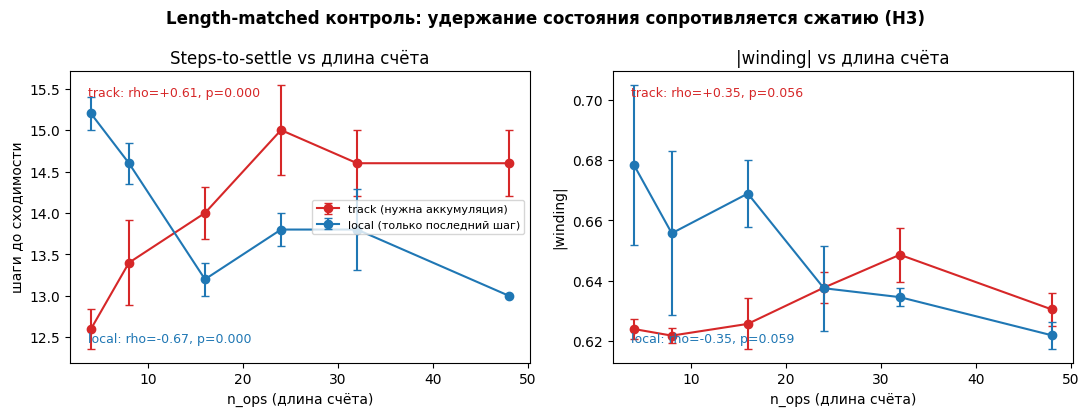

In [21]:
os.makedirs(os.path.join(CACHE, "figures"), exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {"track": "#d62728", "local": "#1f77b4"}
names  = {"track": "track (нужна аккумуляция)", "local": "local (только последний шаг)"}
for ax, metric, ttl, ylab in [
    (axes[0], "steps_settle", "Steps-to-settle vs длина счёта", "шаги до сходимости"),
    (axes[1], "winding",      "|winding| vs длина счёта",       "|winding|")]:
    for kind in ("track", "local"):
        s = ctrl[ctrl.kind == kind]
        g = s.groupby("n_ops")[metric]
        ax.errorbar(g.mean().index, g.mean().values, yerr=g.sem().values,
                    marker="o", capsize=3, color=colors[kind], label=names[kind])
        rho, p = spearmanr(s.n_ops, s[metric])
        ax.text(0.04, 0.95 if kind == "track" else 0.06,
                f"{kind}: rho={rho:+.2f}, p={p:.3f}", transform=ax.transAxes,
                color=colors[kind], va="top" if kind == "track" else "bottom", fontsize=9)
    ax.set_xlabel("n_ops (длина счёта)"); ax.set_ylabel(ylab); ax.set_title(ttl)
axes[0].legend(loc="center right", fontsize=8)
fig.suptitle("Length-matched контроль: удержание состояния сопротивляется сжатию (H3)", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CACHE}/figures/dissociation.png", dpi=150, bbox_inches="tight"); plt.show()
ctrl.to_csv(f"{CACHE}/dissociation_results.csv", index=False)

In [22]:
def compute_ctrl_15():
    rows = []
    for n_ops in tqdm((4, 8, 16, 24, 32, 48), desc="15seed"):
        for s in range(15):                                   # было 5 -> 15
            v = make_variants(n_ops, seed=s)
            for kind in ("track", "local"):
                tr = get_trajectory(v[kind], num_steps=64, seed=0)
                rows.append({"n_ops": n_ops, "kind": kind,
                             "seq_len": int(tok(v[kind], return_tensors="pt").input_ids.shape[1]),
                             "winding": abs(winding_of(tr, burn=4)),
                             "steps_settle": steps_to_settle(tr)})
    return pd.DataFrame(rows)

ctrl = cached("dissociation_15seed.csv", compute_ctrl_15)
for kind in ("track", "local"):
    s = ctrl[ctrl.kind == kind]
    print(kind, "| winding~n_ops:", [round(v,3) for v in spearmanr(s.n_ops, s.winding)],
                "| steps~n_ops:",   [round(v,3) for v in spearmanr(s.n_ops, s.steps_settle)])

15seed: 100%|██████████| 6/6 [30:00<00:00, 300.09s/it]

computed+saved /kaggle/working/dissociation_15seed.csv
track | winding~n_ops: [np.float64(0.324), np.float64(0.002)] | steps~n_ops: [np.float64(0.558), np.float64(0.0)]
local | winding~n_ops: [np.float64(0.054), np.float64(0.61)] | steps~n_ops: [np.float64(-0.576), np.float64(0.0)]


In [24]:
import shutil
os.makedirs("/kaggle/working/repo_upload/figures", exist_ok=True)
for f in ("dissociation_15seed.csv","dissociation.csv","pararule.csv","counting.csv","forceloop.csv"):
    p = f"/kaggle/working/{f}"
    if os.path.exists(p): shutil.copy(p, "/kaggle/working/repo_upload/")
if os.path.isdir("/kaggle/working/figures"):
    shutil.copytree("/kaggle/working/figures", "/kaggle/working/repo_upload/figures", dirs_exist_ok=True)
shutil.make_archive("/kaggle/working/repo_upload", "zip", "/kaggle/working/repo_upload")
print("-> /kaggle/working/repo_upload.zip : скачай из панели Output справа, распакуй в репо")

-> /kaggle/working/repo_upload.zip : скачай из панели Output справа, распакуй в репо


In [25]:
def compute_forceloop():
    rows = []
    for ns in (16, 24, 32, 64):                    # урезаем num_steps = меньше бюджета на сходимость
        for n_ops in (8, 24, 48):
            for s in range(8):
                v = make_variants(n_ops, seed=s)
                tr = get_trajectory(v["track"], num_steps=ns, seed=0)
                rows.append({"num_steps": ns, "n_ops": n_ops,
                             "winding": abs(winding_of(tr, burn=4)),
                             "shape": classify_shape(tr),
                             "steps_settle": steps_to_settle(tr)})
    return pd.DataFrame(rows)

fl = cached("forceloop.csv", compute_forceloop)
print(fl.groupby(["num_steps","n_ops"])["shape"].value_counts())
print(fl.groupby("num_steps")["winding"].mean().round(3))

computed+saved /kaggle/working/forceloop.csv
num_steps  n_ops  shape 
16         8      settle    7
                  loop      1
           24     loop      7
                  settle    1
           48     loop      5
                  settle    2
                  drift     1
24         8      settle    8
           24     settle    8
           48     settle    8
32         8      settle    8
           24     settle    8
           48     settle    8
64         8      settle    8
           24     settle    8
           48     settle    8
Name: count, dtype: int64
num_steps
16    0.648
24    0.634
32    0.636
64    0.633
Name: winding, dtype: float64


computed+saved /kaggle/working/phase.csv


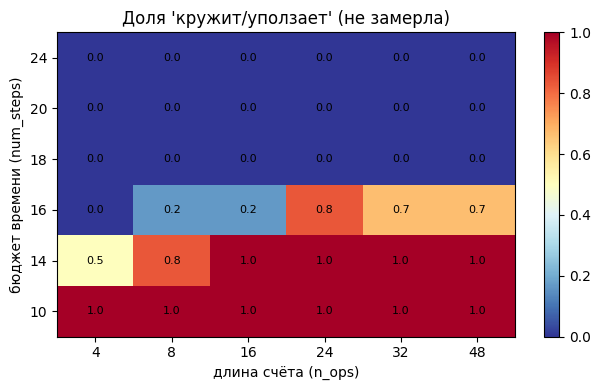

In [26]:
def compute_phase():
    rows = []
    for ns in (10, 14, 16, 18, 20, 24):              # бюджет времени
        for n_ops in (4, 8, 16, 24, 32, 48):         # длина счёта
            for s in range(6):
                v = make_variants(n_ops, seed=s)
                tr = get_trajectory(v["track"], num_steps=ns, seed=0)
                rows.append({"num_steps": ns, "n_ops": n_ops, "regime": classify_shape(tr)})
    return pd.DataFrame(rows)

phase = cached("phase.csv", compute_phase)
phase["unsettled"] = (phase["regime"] != "settle").astype(int)   # 1 = кружит/уползает
grid = phase.pivot_table(index="num_steps", columns="n_ops", values="unsettled", aggfunc="mean")

fig, ax = plt.subplots(figsize=(6.5,4))
im = ax.imshow(grid.values, aspect="auto", origin="lower", cmap="RdYlBu_r", vmin=0, vmax=1)
ax.set_xticks(range(len(grid.columns))); ax.set_xticklabels(grid.columns)
ax.set_yticks(range(len(grid.index)));  ax.set_yticklabels(grid.index)
ax.set_xlabel("длина счёта (n_ops)"); ax.set_ylabel("бюджет времени (num_steps)")
ax.set_title("Доля 'кружит/уползает' (не замерла)")
for i in range(len(grid.index)):
    for j in range(len(grid.columns)):
        ax.text(j, i, f"{grid.values[i,j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig(f"{CACHE}/figures/phase.png", dpi=150, bbox_inches="tight"); plt.show()

In [27]:
def make_switch_task(n_ops, seed=0):
    rng = random.Random(seed)
    flips = [rng.choice([0, 1]) for _ in range(n_ops)]
    body = "Light is off. " + " ".join("Flip." if f else "Wait." for f in flips)
    return {"prompt": body + " Is the light on? A:", "answer": "on" if sum(flips) % 2 else "off"}

def compute_switch():
    rows = []
    for n_ops in tqdm((4, 8, 16, 24, 32, 48), desc="switch"):
        for s in range(10):
            t = make_switch_task(n_ops, seed=s)
            tr = get_trajectory(t["prompt"], num_steps=64, seed=0)
            rows.append({"n_ops": n_ops,
                         "winding": abs(winding_of(tr, burn=4)),
                         "steps_settle": steps_to_settle(tr)})
    return pd.DataFrame(rows)

sw = cached("switch.csv", compute_switch)
print("switch | winding~n_ops:", [round(v,3) for v in spearmanr(sw.n_ops, sw.winding)],
      "| steps~n_ops:", [round(v,3) for v in spearmanr(sw.n_ops, sw.steps_settle)])

switch: 100%|██████████| 6/6 [07:56<00:00, 79.45s/it]

computed+saved /kaggle/working/switch.csv
switch | winding~n_ops: [np.float64(0.162), np.float64(0.215)] | steps~n_ops: [np.float64(0.615), np.float64(0.0)]
